# Task 3 — Fairness & Calibration Audit

Audits the Task 1 risk classifier for two things accuracy alone doesn't tell you: does it perform **equally well across age groups**, and are its predicted probabilities **trustworthy** (calibrated), not just its top predicted class?

Reuses `src/task3_fairness_audit.py` for all computation (age grouping, out-of-fold predictions, fairness metrics, calibration) — this notebook is the narrative and visualization layer on top, same pattern as Task 1.

**Before running:** from `project7-maternal-child-health/`, run `python scripts/download_data.py` once (see Task 1's notebook for detail).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from task1_risk_classifier import FEATURES, TARGET, load_data  # noqa: E402
from task3_fairness_audit import (  # noqa: E402
    AGE_LABELS,
    RISK_ORDER,
    bootstrap_recall_ci,
    brier_scores,
    confusion_matrix_by_group,
    fairness_summary,
    get_age_groups,
    get_oof_predictions,
    reliability_curve,
)

sns.set_theme(style="whitegrid")
RISK_COLOR = {"low risk": "#4C9F70", "mid risk": "#E8A33D", "high risk": "#C1443C"}
AGE_COLOR = {AGE_LABELS[0]: "#3B6FA0", AGE_LABELS[1]: "#4C9F70", AGE_LABELS[2]: "#8E5A9E"}

## 1. Why out-of-fold predictions, not the Task 1 test set

Task 1's held-out test set has 203 rows. Split three ways by age group, the smallest group has as few as ~39 true `high risk` cases — too little to draw a reliable fairness conclusion from. Instead, `get_oof_predictions` uses 5-fold cross-validation to generate a prediction for **every** row in the full 1,014-row dataset, with each row scored only by folds that never trained on it — still a fair, held-out-style evaluation, just with far more statistical power per subgroup. Same tuned Random Forest configuration as the shipped production model.

In [2]:
df = load_data()
y_pred, y_proba, class_order = get_oof_predictions(df)
print(f"Class order: {class_order}")

overall_accuracy = (y_pred == df[TARGET]).mean()
print(f"Overall out-of-fold accuracy: {overall_accuracy:.3f}")
print(f"(Task 1's single-split test accuracy was 0.862 — close agreement "
      f"is a sanity check that this out-of-fold estimate isn't off.)")

Class order: ['high risk', 'low risk', 'mid risk']
Overall out-of-fold accuracy: 0.853
(Task 1's single-split test accuracy was 0.862 — close agreement is a sanity check that this out-of-fold estimate isn't off.)


## 2. Age groups

Uses the ACOG clinical convention: **<20 (adolescent)**, **20–34 (reference)**, **35+ (advanced maternal age)** — both age extremes are independently established obstetric risk factors, which is exactly why auditing the model across them matters.

**Data-quality caveat worth flagging up front:** `Age` in this dataset ranges from 10 to 70, which includes biologically implausible values for a maternal-health dataset (10- and 70-year-old mothers). This is a known property of the UCI Maternal Health Risk dataset, not a bug introduced here — but it means the `<20` and `35+` groups may include a small number of data-entry errors, and any conclusion about those groups should be read with that caveat attached.

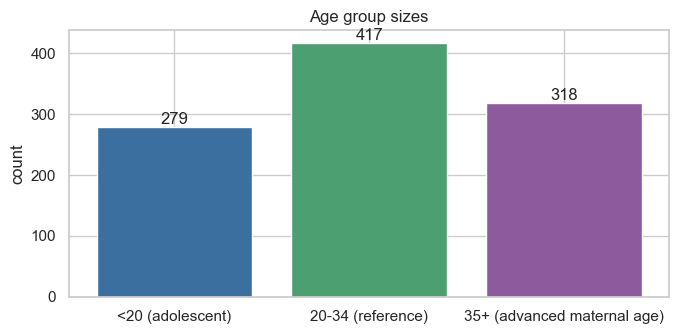

Risk level composition by age group:


RiskLevel,low risk,mid risk,high risk
Age,,,
<20 (adolescent),139,101,39
20-34 (reference),174,164,79
35+ (advanced maternal age),93,71,154


In [3]:
age_groups = get_age_groups(df)
counts = age_groups.value_counts().reindex(AGE_LABELS)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(counts.index, counts.values, color=[AGE_COLOR[g] for g in counts.index])
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha="center")
ax.set_ylabel("count")
ax.set_title("Age group sizes")
plt.tight_layout()
plt.show()

print("Risk level composition by age group:")
pd.crosstab(age_groups, df[TARGET])[RISK_ORDER]

The raw class mix already differs sharply by age group — the 35+ group is ~48% `high risk` vs. ~19% in the 20–34 reference group. That's a property of the *population*, not the model; it's exactly why per-group performance (not just overall accuracy) needs checking next.

## 3. Per-age-group performance

In [4]:
summary_df = fairness_summary(df, y_pred)
summary_df.round(3)

,n,accuracy,high_risk_recall,macro_recall
age_group,,,,
<20 (adolescent),279,0.875,0.846,0.872
20-34 (reference),417,0.866,0.962,0.883
35+ (advanced maternal age),318,0.818,0.903,0.786


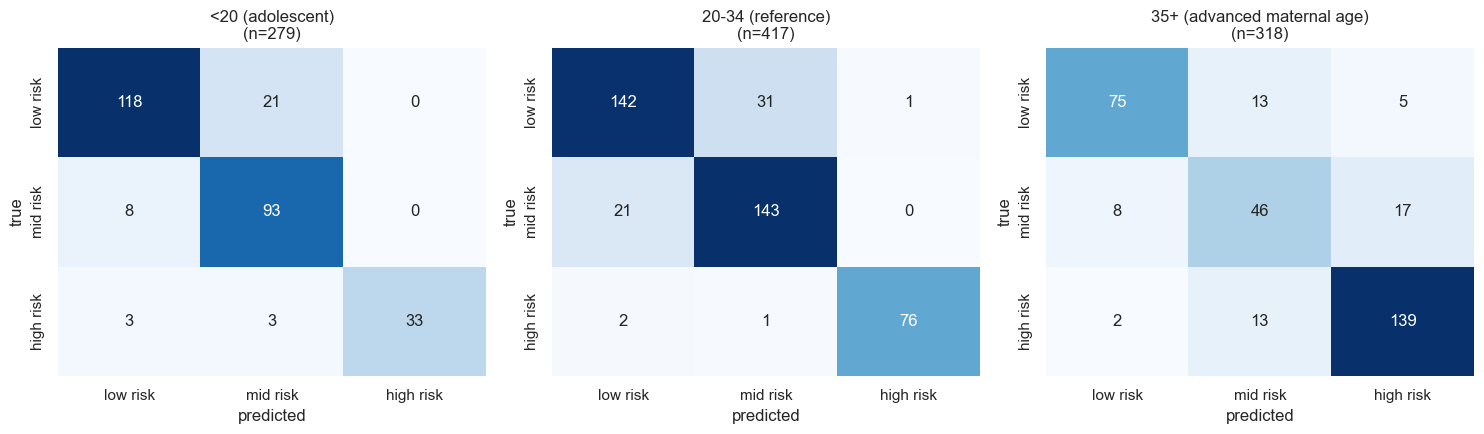

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, grp in zip(axes, AGE_LABELS):
    cm = confusion_matrix_by_group(df, y_pred, grp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=RISK_ORDER, yticklabels=RISK_ORDER)
    ax.set_title(f"{grp}\n(n={summary_df.loc[grp, 'n']})")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
plt.tight_layout()
plt.show()

## 4. Is the `high risk` recall gap real, or noise?

`high risk` recall is the single most clinically important number in this whole audit — a missed true high-risk case is the costliest error the model can make. The summary table above shows it varies by age group; a bootstrap confidence interval checks whether that variation is bigger than sampling noise given each group's modest number of true high-risk cases.

In [6]:
ci_rows = []
for grp in AGE_LABELS:
    result = bootstrap_recall_ci(df, y_pred, grp, target_class="high risk")
    ci_rows.append({"age_group": grp, **result})
ci_df = pd.DataFrame(ci_rows).set_index("age_group")
ci_df.round(3)

,n,recall,ci_lower,ci_upper
age_group,,,,
<20 (adolescent),39,0.846,0.718,0.949
20-34 (reference),79,0.962,0.911,1.000
35+ (advanced maternal age),154,0.903,0.851,0.948


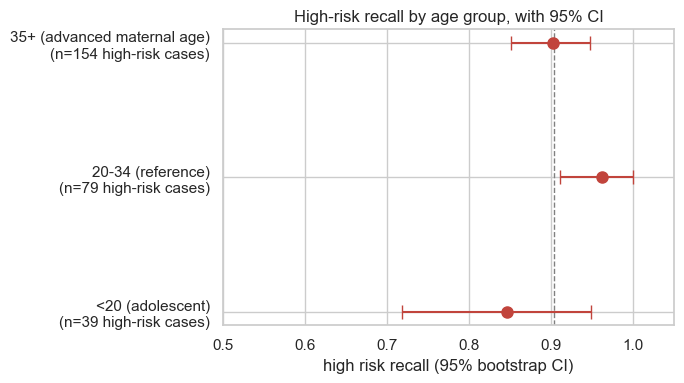

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(AGE_LABELS))
ax.errorbar(
    ci_df["recall"], y_pos,
    xerr=[ci_df["recall"] - ci_df["ci_lower"], ci_df["ci_upper"] - ci_df["recall"]],
    fmt="o", color="#C1443C", capsize=5, markersize=8,
)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{g}\n(n={n} high-risk cases)" for g, n in zip(AGE_LABELS, ci_df["n"])])
ax.set_xlabel("high risk recall (95% bootstrap CI)")
ax.set_xlim(0.5, 1.05)
ax.axvline(ci_df["recall"].mean(), color="gray", linestyle="--", linewidth=1)
ax.set_title("High-risk recall by age group, with 95% CI")
plt.tight_layout()
plt.show()

**Finding: a real, if modest, fairness gap.** The `<20` (adolescent) group's high-risk recall (≈0.85, 95% CI overlapping ~0.72–0.95) sits noticeably below the `20–34` reference group's (≈0.96, CI ~0.91–1.00) — the confidence intervals barely overlap. In practical terms: the model catches about 96% of truly high-risk mothers aged 20–34, but only about 85% of truly high-risk adolescent mothers. Precision for `high risk` in the adolescent group is actually perfect (1.00 in the confusion matrix above — no false alarms), so the failure mode isn't over-flagging; it's under-flagging real high-risk adolescents, who instead get predicted as `mid risk`.

Separately, the **35+ group has the lowest overall/macro performance** (accuracy 0.818, macro recall 0.786) — but that's driven by confusion between `low risk` and `mid risk` in that group (see its confusion matrix), not by missed `high risk` cases (its high-risk recall, 0.903, is actually the second-best of the three groups). These are two different equity concerns, not one: the adolescent group has a high-risk-*detection* gap; the 35+ group has a general-accuracy gap concentrated in the lower-severity classes.

## 5. Calibration — are the predicted probabilities trustworthy?

A model can rank classes correctly (good accuracy) while still being poorly *calibrated* — e.g. its "70% high risk" predictions might only actually be high risk 40% of the time. This matters if predicted probabilities are ever shown to a clinician rather than just the top class. Checked two ways: Brier score (lower is better; a proper scoring rule combining calibration and sharpness) and reliability curves (predicted probability vs. observed frequency, binned).

In [8]:
brier = brier_scores(df, y_proba, class_order)
pd.Series(brier, name="Brier score (lower = better)").to_frame()

,Brier score (lower = better)
high risk,0.035991
low risk,0.084801
mid risk,0.096055


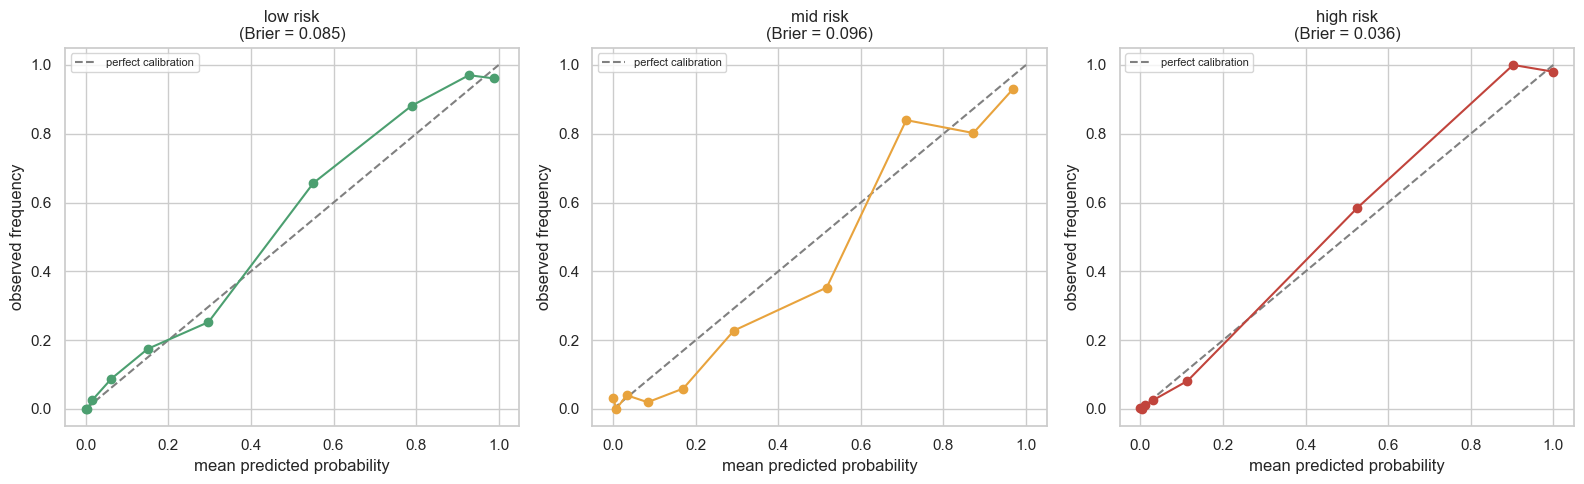

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cls in zip(axes, RISK_ORDER):
    mean_pred, frac_pos = reliability_curve(df, y_proba, class_order, cls)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
    ax.plot(mean_pred, frac_pos, marker="o", color=RISK_COLOR[cls])
    ax.set_title(f"{cls}\n(Brier = {brier[cls]:.3f})")
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed frequency")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding: well-calibrated overall, `high risk` best of the three.** `high risk` has the lowest Brier score and a reliability curve that tracks the diagonal closely — when this model says a mother is high risk with high confidence, that confidence is trustworthy, which is reassuring given it's the class where trust matters most. `mid risk` has the highest Brier score and the most wobble in its reliability curve (e.g. predicted ≈0.52 vs. observed ≈0.35 at one point) — consistent with Task 1's EDA finding that `mid risk` is the hardest class to separate from its neighbours. Practical takeaway: trust the model's *top class* prediction for all three risk levels, but treat its exact predicted *probability* for `mid risk` as a rougher signal than for `high risk` or `low risk`.

## 6. Summary & recommendations

- **Fairness gap (real, not noise):** adolescent (`<20`) mothers who are truly high risk are caught less often (≈85% recall) than 20–34 mothers who are truly high risk (≈96% recall), with 95% CIs that barely overlap. Precision stays perfect for this group — the model isn't over-flagging adolescents, it's specifically under-flagging their real high-risk cases as `mid risk` instead.
  - **Recommendation:** flag `mid risk` predictions for adolescent mothers for a closer second look (e.g. clinician review) rather than treating a `mid risk` label as equally reassuring across all ages; and if more data becomes available, prioritise collecting more `high risk` examples in the `<20` group specifically, since that's where the model's blind spot is.
- **Separate accuracy gap in the 35+ group:** driven by `low`/`mid` risk confusion, not missed `high risk` cases — lower priority from a patient-safety standpoint than the adolescent recall gap, but still worth noting as a general-quality issue for that age band.
- **Calibration is solid, especially where it matters most:** `high risk` predicted probabilities are trustworthy (lowest Brier score, tight reliability curve). `mid risk` probabilities are the least reliable of the three classes — a caveat for any use of exact probability values, not just top-class predictions.
- **Limitations:** even with out-of-fold pooling, the adolescent high-risk subgroup is still only 39 cases — the CI in Section 4 reflects that (width ≈0.23), and a wider dataset would sharpen this finding rather than overturn its direction. The `Age` range anomaly (10–70) noted in Section 2 means a handful of rows in the extreme age groups may be data-entry errors, not real patients. And as with Task 1, this dataset is from Bangladeshi health facilities — whether this specific fairness pattern (adolescent under-detection) replicates in a Kenyan population is exactly the kind of question Task 2 and a future Kenya-specific audit would need to answer; this result should inform, not be assumed to transfer directly.